In [1]:
import os, io, random
import numpy as np
from collections import Counter
from PIL import Image

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, ConcatDataset, random_split
from torchvision import datasets, transforms as T


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True  # Speed

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

def count_classes(dataset):
    return Counter([int(label) for _, label in dataset])


Using device: cuda


In [ ]:
class FaceOnly:
    """
    Face detector + crop (Haarcascade).
    """
    def __init__(self, scale=1.2, bg_value=128):
        self.scale = scale
        self.bg_value = bg_value

        possible_paths = [
            os.path.join(os.path.dirname(cv2.__file__), "data", "haarcascade_frontalface_default.xml"),
            "/usr/share/opencv4/haarcascades/haarcascade_frontalface_default.xml",
            "/usr/share/opencv/haarcascades/haarcascade_frontalface_default.xml",
            "/usr/local/share/opencv4/haarcascades/haarcascade_frontalface_default.xml",
            "/usr/local/lib/python3.11/dist-packages/cv2/data/haarcascade_frontalface_default.xml",
            "/usr/local/lib/python3.10/dist-packages/cv2/data/haarcascade_frontalface_default.xml",
            "/usr/lib/python3/dist-packages/cv2/data/haarcascade_frontalface_default.xml",
        ]
        cascade_path = next((p for p in possible_paths if os.path.exists(p)), None)
        if cascade_path is None:
            raise FileNotFoundError("⚠️ Haarcascade wurde nicht gefunden.")
        print("✔ Haarcascade geladen aus:", cascade_path)
        self.detector = cv2.CascadeClassifier(cascade_path)


class RandomJPEGCompression:
    def __init__(self, quality_range=(35, 85)):
        self.quality_range = quality_range

    def __call__(self, img):
        quality = int(np.random.uniform(*self.quality_range))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=quality, optimize=True)
        buf.seek(0)
        return Image.open(buf).convert("RGB")


def find_imagefolder_root(base_path, required_any_of):
    """
    Findet Root, in dem direkt die Klassenordner liegen.
    required_any_of: dict {"Fake":[...], "Real":[...]} -> pro Klasse muss mind. ein Alias existieren.
    """
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Pfad existiert nicht: {base_path}")

    def matches(dirs):
        lower = {d.lower() for d in dirs}
        for _, aliases in required_any_of.items():
            if not any(a.lower() in lower for a in aliases):
                return False
        return True


    try:
        dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
        if matches(dirs):
            return base_path
    except Exception:
        pass


    for root, dirs, _ in os.walk(base_path):
        if matches(dirs):
            return root

    raise RuntimeError(f"Keinen ImageFolder-Root gefunden unter: {base_path}")


class RemapLabelsDataset(torch.utils.data.Dataset):
    """
    Mappt Dataset-Klassen wie fake/deepfake/real -> Fake/Real -> 0/1
    """
    def __init__(self, base_dataset, target_class_to_idx, alias_to_target):
        self.base = base_dataset
        self.target_class_to_idx = target_class_to_idx
        self.alias_to_target = {k.lower(): v for k, v in alias_to_target.items()}
        self.idx_to_class = {v: k for k, v in self.base.class_to_idx.items()}

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, y = self.base[idx]
        cls = self.idx_to_class[int(y)].lower()
        if cls not in self.alias_to_target:
            raise KeyError(f"Unbekannte Klasse '{cls}' – alias_to_target erweitern.")
        target = self.alias_to_target[cls]              # "Fake"/"Real"
        y2 = self.target_class_to_idx[target]           # 0/1
        return img, y2


In [ ]:
# BUILD DATASET + SMALL SAMPLE + HAAR 

class_aliases = {
    "Fake": ["fake", "deepfake"],
    "Real": ["real"]
}
alias_to_target = {"fake":"Fake", "deepfake":"Fake", "real":"Real"}
target_class_to_idx = {"Fake": 0, "Real": 1}

specs = [
    {"name":"60k", "base":"/kaggle/input/deepfake-vs-real-60k/deepfake-vs-real-60k"},
    {"name":"20k", "base":"/kaggle/input/deepfake-vs-real-20k"},
]

datasets_list = []
raw_list = []

for s in specs:
    root = find_imagefolder_root(s["base"], class_aliases)
    ds_raw = datasets.ImageFolder(root=root, transform=None)  # kein transform
    ds = RemapLabelsDataset(ds_raw, target_class_to_idx, alias_to_target)  
    print(f"{s['name']} root:", root, "| classes:", ds_raw.classes)
    datasets_list.append(ds)
    raw_list.append(ds_raw)

# Small Dataset balanced 
USE_SMALL_SAMPLE = True
SAMPLES_PER_DATASET = 6000
SEED = 42

def balanced_indices_from_imagefolder(ds_raw, n_total, seed=42):
    assert n_total % 2 == 0
    n_per = n_total // 2
    idx_to_classname = {v: k for k, v in ds_raw.class_to_idx.items()}

    fake_idx, real_idx = [], []
    for i, (_, c) in enumerate(ds_raw.samples):
        name = idx_to_classname[int(c)].lower()
        if name not in alias_to_target:
            continue
        if alias_to_target[name] == "Fake":
            fake_idx.append(i)
        else:
            real_idx.append(i)

    g = torch.Generator().manual_seed(seed)
    fake_idx = torch.tensor(fake_idx)[torch.randperm(len(fake_idx), generator=g)].tolist()
    real_idx = torch.tensor(real_idx)[torch.randperm(len(real_idx), generator=g)].tolist()

    take_f = fake_idx[:min(n_per, len(fake_idx))]
    take_r = real_idx[:min(n_per, len(real_idx))]
    m = min(len(take_f), len(take_r))
    return take_f[:m] + take_r[:m]

if USE_SMALL_SAMPLE:
    sampled_list = []
    for j, (ds, ds_raw) in enumerate(zip(datasets_list, raw_list)):
        idx = balanced_indices_from_imagefolder(ds_raw, SAMPLES_PER_DATASET, seed=SEED + j)
        ds_small = Subset(ds, idx)
        print(f"Small sample Dataset {j}: requested={SAMPLES_PER_DATASET} -> got={len(ds_small)} (balanced)")
        sampled_list.append(ds_small)
    dataset_base = ConcatDataset(sampled_list)   
else:
    dataset_base = ConcatDataset(datasets_list)

print("dataset_base size:", len(dataset_base))


face_detector = FaceOnly(scale=1.0).detector

def detect_face_box(img_pil, downscale=0.5):
    img_np = np.array(img_pil)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    if downscale != 1.0:
        small = cv2.resize(gray, (0, 0), fx=downscale, fy=downscale, interpolation=cv2.INTER_AREA)
    else:
        small = gray

    faces = face_detector.detectMultiScale(small, 1.15, 5, minSize=(40, 40))
    if len(faces) == 0:
        return None

    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    if downscale != 1.0:
        inv = 1.0 / downscale
        x = int(x * inv); y = int(y * inv); w = int(w * inv); h = int(h * inv)
    return (x, y, w, h)

bbox_cache = {}
valid = []
skipped = 0

print("LEN(dataset_base) before haar:", len(dataset_base))

for i in range(len(dataset_base)):
    img, y = dataset_base[i]           # PIL + label (0/1)
    box = detect_face_box(img, downscale=0.5)
    if box is None:
        skipped += 1
    else:
        bbox_cache[i] = box         
        valid.append(i)

print("Skipped no-face:", skipped)

dataset_faces = Subset(dataset_base, valid)      # only faces
print("dataset_faces size:", len(dataset_faces))

DATASET_READY = True
assert DATASET_READY


60k root: /kaggle/input/deepfake-vs-real-60k/deepfake-vs-real-60k | classes: ['Fake', 'Real']
20k root: /kaggle/input/deepfake-vs-real-20k/Deep-vs-Real | classes: ['Deepfake', 'Real']
Small sample Dataset 0: requested=6000 -> got=6000 (balanced)
Small sample Dataset 1: requested=6000 -> got=6000 (balanced)
dataset_base size: 12000
✔ Haarcascade geladen aus: /usr/local/lib/python3.11/dist-packages/cv2/data/haarcascade_frontalface_default.xml
LEN(dataset_base) before haar: 12000
Skipped no-face: 2568
dataset_faces size: 9432


In [4]:
# ======================
# SPLIT
# ======================
from torch.utils.data import random_split

seed = 42

train_ratio = 0.7
val_ratio   = 0.1
test_ratio  = 0.2

assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios müssen 1.0 ergeben."

n = len(dataset_faces)

n_train = int(train_ratio * n)
n_val   = int(val_ratio * n)
n_test  = n - n_train - n_val   

train_subset, val_subset, test_subset = random_split(
    dataset_faces, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(seed)
)

print("Total:", n)
print("Train:", len(train_subset), "| Val:", len(val_subset), "| Test:", len(test_subset))


Total: 9432
Train: 6602 | Val: 943 | Test: 1887


In [ ]:
# ==========================
# CONFIG 
# ==========================


class FaceCropTransformSubset(torch.utils.data.Dataset):
    """
    subset: random_split subset (train_subset / val_subset / test_subset) auf dataset_faces
    dataset_faces: Subset(dataset_base, valid)
    bbox_cache keys: indices in dataset_base
    """
    def __init__(self, subset, dataset_faces, bbox_cache, transform=None, scale=1.2):
        self.subset = subset
        self.dataset_faces = dataset_faces
        self.bbox_cache = bbox_cache
        self.transform = transform
        self.scale = scale

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        face_idx = self.subset.indices[idx]                 
        base_idx = self.dataset_faces.indices[face_idx]    

        img, label = self.dataset_faces.dataset[base_idx]  
        x, y, w, h = self.bbox_cache[base_idx]

        img_np = np.array(img)
        H, W = img_np.shape[:2]
        cx, cy = x + w // 2, y + h // 2
        side = int(max(w, h) * self.scale)

        x1 = max(0, cx - side // 2); y1 = max(0, cy - side // 2)
        x2 = min(W, cx + side // 2); y2 = min(H, cy + side // 2)

        crop = Image.fromarray(img_np[y1:y2, x1:x2])

        if self.transform is None:
            return crop, label
        return self.transform(crop), label


train_transform_no_face = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=(-10, 10), expand=False, fill=(128, 128, 128)),
    T.ColorJitter(brightness=0.15, contrast=0.20, saturation=0.15, hue=0.09),
    T.RandomApply([RandomJPEGCompression((35, 85))], p=0.10),
    T.RandomApply([T.GaussianBlur(3, sigma=(0.4, 1.2))], p=0.2),
    T.RandomGrayscale(p=0.09),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform_no_face = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


TRAIN_FACE_SCALE = 1.0
EVAL_FACE_SCALE  = 1.0  

train_data = FaceCropTransformSubset(train_subset, dataset_faces, bbox_cache, transform=train_transform_no_face, scale=TRAIN_FACE_SCALE)
val_data   = FaceCropTransformSubset(val_subset,   dataset_faces, bbox_cache, transform=eval_transform_no_face,  scale=EVAL_FACE_SCALE)
test_data  = FaceCropTransformSubset(test_subset,  dataset_faces, bbox_cache, transform=eval_transform_no_face,  scale=EVAL_FACE_SCALE)


batch_size = 32
num_workers = 4
pin = (device.type == "cuda")

persistent = (num_workers > 0)
prefetch = 2 if num_workers > 0 else None

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch if prefetch is not None else 2
) if num_workers > 0 else DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch if prefetch is not None else 2
) if num_workers > 0 else DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch if prefetch is not None else 2
) if num_workers > 0 else DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

print("Loaders ready.")
print("  Train batches:", len(train_loader))
print("  Val   batches:", len(val_loader))
print("  Test  batches:", len(test_loader))


Loaders ready.
  Train batches: 207
  Val   batches: 30
  Test  batches: 59


In [ ]:

attention_maps = []

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=384):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, E, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, N_patches, E)
        return x


class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        # +1 für CLS-Token
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))

    def forward(self, x):
        return x + self.pos_embed


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=False)

    def forward(self, x):
        # x: (B, S, E) -> (S, B, E) für MultiheadAttention
        x = x.transpose(0, 1)
        
        out, weights = self.attn(x, x, x, need_weights=True)
        
        
        if not self.training:
            # Wir detachen, damit der Graph nicht gesprengt wird
            attention_maps.append(weights.detach().cpu())
        # ---------------------
            
        out = out.transpose(0, 1)
        return out


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, attn_dropout=0.0):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads, attn_dropout=attn_dropout)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout1(self.attn(self.norm1(x)))
        x = x + self.dropout2(self.mlp(self.norm2(x)))
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        num_classes=2,   

        embed_dim=384,   
        num_heads=6,     
        depth=8,         
        mlp_dim=1536,   

        dropout=0.1,
        attn_dropout=0.0,
        head_dropout=0.2
    
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        num_patches = (img_size // patch_size) ** 2
        self.pos_encoding = PositionalEncoding(embed_dim, num_patches)

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout,
                attn_dropout=attn_dropout
            )
            for _ in range(depth)
        ])

      
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Dropout(head_dropout),
            nn.Linear(mlp_dim, num_classes)
        )

    def forward(self, x):
       
        if not self.training:
            global attention_maps
            attention_maps = []
        # ---------------------

        B = x.size(0)
        x = self.patch_embedding(x)          # (B, N_patches, E)

        cls_tokens = self.cls_token.expand(B, 1, -1)  # (B, 1, E)
        x = torch.cat((cls_tokens, x), dim=1)         # (B, 1 + N_patches, E)

        x = self.pos_encoding(x)

        for block in self.transformer_blocks:
            x = block(x)

        cls_repr = x[:, 0]                   # CLS-Token
        logits = self.mlp_head(cls_repr)
        return logits

print("loaded")

loaded


In [7]:
class_names = ['Fake', 'Real']

def visualize_attention(model, img_tensor, original_image_np):
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()

    if len(attention_maps) == 0:
        print("Keine Attention Maps gefunden.")
        return

    att = attention_maps[-1]  # letzter Layer

    if att.dim() == 4:
        # (B,H,T,T) -> mean over heads
        att_mat = att.mean(dim=1)[0]          # (T,T)
    elif att.dim() == 3:
        # (B,T,T) oder (H,T,T)
        if att.shape[0] == img_tensor.shape[0]:  # att[0] ist batch
            att_mat = att[0]                    # (T,T)
        else:
            att_mat = att.mean(dim=0)           # (T,T) mean over heads
    else:
        raise ValueError(f"Unexpected attention shape: {att.shape}")

    # CLS -> patches
    cls_attention = att_mat[0, 1:]  # (T-1,)
    grid_size = int(np.sqrt(cls_attention.numel()))

    attn_heatmap = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

    # resize to original image size
    attn_heatmap = cv2.resize(attn_heatmap, (original_image_np.shape[1], original_image_np.shape[0]))

    # normalize safely
    denom = (attn_heatmap.max() - attn_heatmap.min())
    if denom < 1e-8:
        attn_heatmap = np.zeros_like(attn_heatmap)
    else:
        attn_heatmap = (attn_heatmap - attn_heatmap.min()) / denom

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(original_image_np)
    ax[0].set_title(f"Vorhersage: {class_names[pred_idx]}\nConf: {probs[0, pred_idx].item():.2f}")
    ax[0].axis('off')

    ax[1].imshow(original_image_np)
    ax[1].imshow(attn_heatmap, cmap='jet', alpha=0.5)
    ax[1].set_title("ViT Attention (mean over heads, last layer)")
    ax[1].axis('off')

    plt.show()


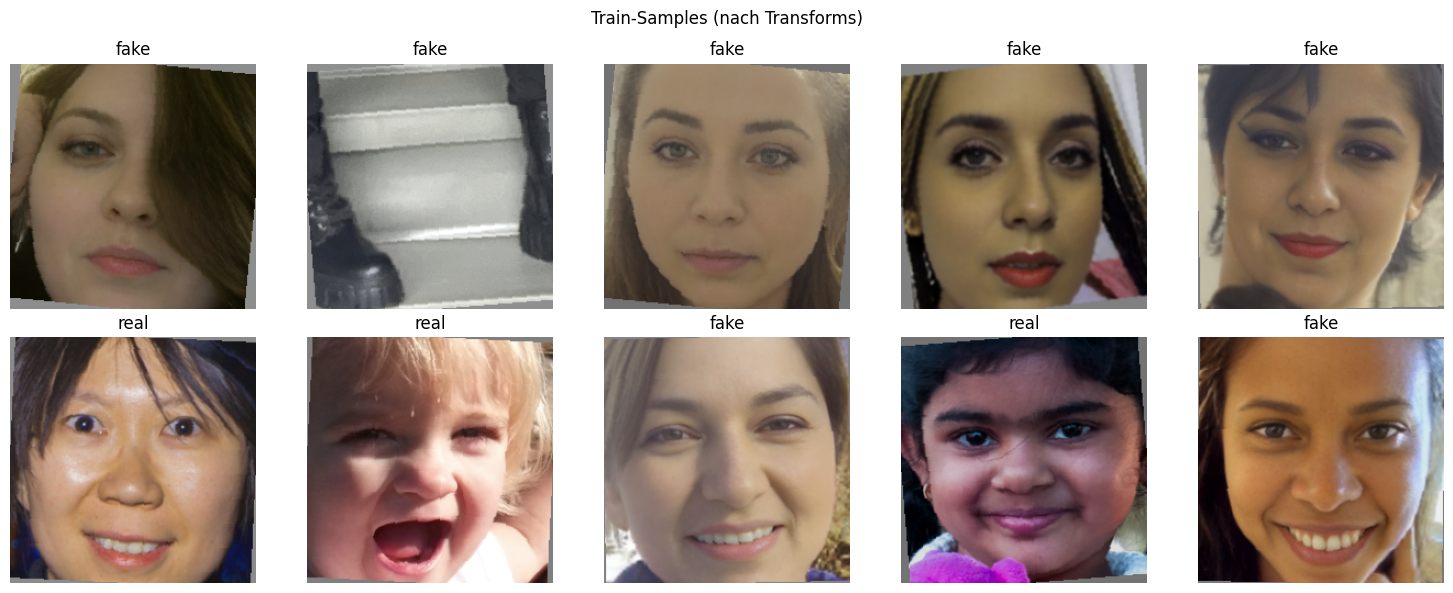

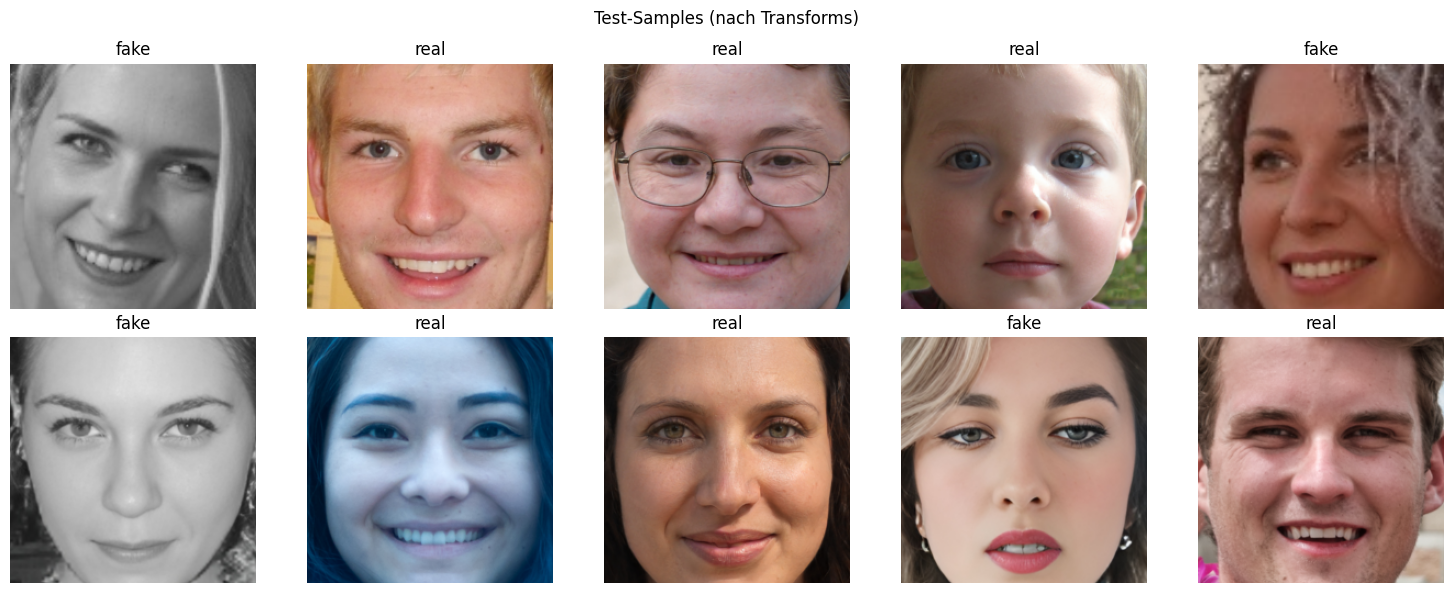

In [8]:

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    """
    img_tensor: (3, H, W), normalisiert
    -> (H, W, 3) numpy in [0,1]
    """
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).cpu().numpy()
    return img

def show_samples(dataset, classes, num=1, title="Samples"):
    """
    dataset: z.B. train_data oder test_data
    classes: Klassenliste, z.B. ['fake', 'real']
    """
    num = min(num, len(dataset))
    indices = torch.randperm(len(dataset))[:num]

    cols = 5
    rows = (num + cols - 1) // cols

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i, idx in enumerate(indices):
        img, label = dataset[idx]  # img ist schon normalisiert (Tensor)
        img_np = denormalize(img)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img_np)
        ax.set_title(classes[label])
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# Klassenliste aus dataset1 (['fake', 'real'])
classes = (['fake', 'real'])

# 10 Trainingsbilder
show_samples(train_data, classes, num=10, title="Train-Samples (nach Transforms)")

# 10 Testbilder
show_samples(test_data, classes, num=10, title="Test-Samples (nach Transforms)")


In [ ]:
# ==========================
# TRAINING 
# ==========================
import copy


num_epochs = 40

model = VisionTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=3e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)
print(model)

def evaluate(model, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_loss = total_loss / max(1, len(data_loader))
    acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, acc

train_losses = []
val_losses = []
val_accuracies = []

# -------------------------
# EARLY-STOPPING-SETUP
# -------------------------
patience = 6
best_val_loss = float("inf")
best_epoch = -1
best_model_state = None
no_improve_count = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            avg_loss = running_loss / (batch_idx + 1)
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f} (avg: {avg_loss:.4f})")

    epoch_train_loss = running_loss / max(1, len(train_loader))
    train_losses.append(epoch_train_loss)

    #  Validation 
    val_loss, val_acc = evaluate(model, val_loader)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Early stopping on val_loss
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())  # ✅ sicher
        no_improve_count = 0
        print(f"  ↳ Neue beste Val-Loss! (epoch {epoch+1})")
    else:
        no_improve_count += 1
        print(f"  ↳ Keine Verbesserung ({no_improve_count}/{patience})")
        if no_improve_count >= patience:
            print(f"\n⏹ Early stopping nach Epoch {epoch+1}. "
                  f"Bestes Modell war Epoch {best_epoch+1} mit Val-Loss {best_val_loss:.4f}.")
            break

# bestes Modell wiederherstellen
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✔ Bestes Modell aus Epoch {best_epoch+1} geladen.")

#  Finaler Test
test_loss, test_acc = evaluate(model, test_loader)
print(f"FINAL TEST - Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")


VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_encoding): PositionalEncoding()
  (transformer_blocks): ModuleList(
    (0-7): 8 x TransformerEncoderBlock(
      (attn): MultiHeadAttention(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
      )
      (mlp): Sequential(
        (0): Linear(in_features=384, out_features=1536, bias=True)
        (1): ReLU()
        (2): Linear(in_features=1536, out_features=384, bias=True)
      )
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=384, out_features=1536,

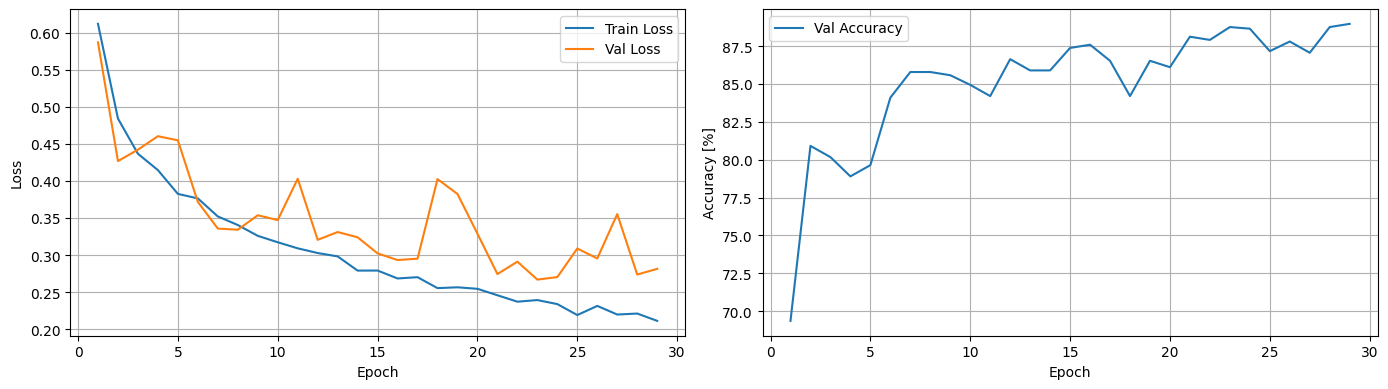

In [10]:
# Trainings- und Validierungsverluste / Accuracy plotten
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy [%]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ==========================
# FINAL TEST CHECK
# ==========================
model.eval()
test_loss, test_acc = evaluate(model, test_loader)
print(f"FINAL TEST - Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")

FINAL TEST - Loss: 0.2478, Acc: 89.51%


In [12]:

model.eval()

save_path = "vit_deepfake.pth"
torch.save(model.state_dict(), save_path)
print("Modellgewichte gespeichert unter:", save_path)

Modellgewichte gespeichert unter: vit_deepfake.pth


✔ Haarcascade geladen aus: /usr/local/lib/python3.11/dist-packages/cv2/data/haarcascade_frontalface_default.xml


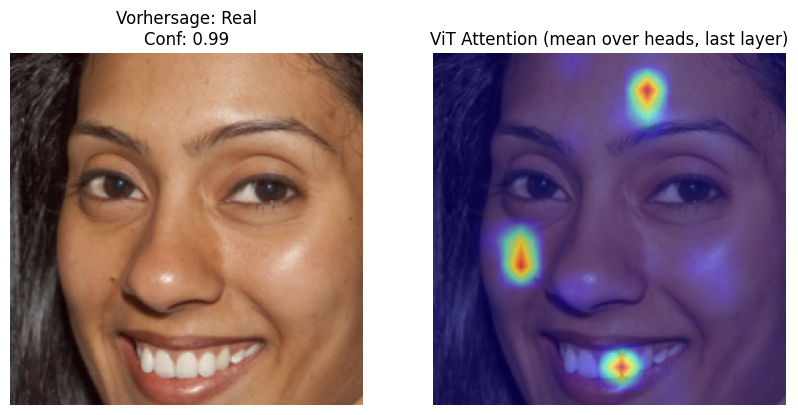

In [ ]:
# Test sample mit Attention-Visualisierung
test_compose = test_data.transform  

# Face detector 
face_detector = FaceOnly(scale=1.0).detector

def detect_face_box_single(img_pil, downscale=0.5):
    img_np = np.array(img_pil)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    if downscale != 1.0:
        small = cv2.resize(gray, (0, 0), fx=downscale, fy=downscale, interpolation=cv2.INTER_AREA)
    else:
        small = gray

    faces = face_detector.detectMultiScale(small, 1.15, 5, minSize=(40, 40))
    if len(faces) == 0:
        return None

    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    if downscale != 1.0:
        inv = 1.0 / downscale
        x = int(x * inv); y = int(y * inv); w = int(w * inv); h = int(h * inv)
    return (x, y, w, h)

def crop_with_box(img_pil, box, scale=1.0):
    x, y, w, h = box
    img_np = np.array(img_pil)
    H, W = img_np.shape[:2]
    cx, cy = x + w//2, y + h//2
    side = int(max(w, h) * scale)

    x1 = max(0, cx - side//2); y1 = max(0, cy - side//2)
    x2 = min(W, cx + side//2); y2 = min(H, cy + side//2)
    return Image.fromarray(img_np[y1:y2, x1:x2])

def preprocess_single_like_training(pil_img, face_scale=1.0):
    box = detect_face_box_single(pil_img, downscale=0.5)
    if box is not None:
        pil_face = crop_with_box(pil_img, box, scale=face_scale)
    else:
        pil_face = pil_img  # fallback

    
    def split_compose(comp):
        pre, post = [], []
        after = False
        for tr in comp.transforms:
            if isinstance(tr, T.ToTensor):
                after = True
                post.append(tr)
            elif after:
                post.append(tr)
            else:
                pre.append(tr)
        return T.Compose(pre), T.Compose(post)

    pre_t, post_t = split_compose(test_compose)
    pre_pil = pre_t(pil_face)
    x = post_t(pre_pil).unsqueeze(0).to(device)
    img_np = np.array(pre_pil)
    return x, img_np

# Beispiel
image_path = "/kaggle/input/deepfake-vs-real-60k/deepfake-vs-real-60k/Real/0001 (22997).png"
pil_img = Image.open(image_path).convert("RGB")
input_tensor, img_np = preprocess_single_like_training(pil_img, face_scale=1.0)

visualize_attention(model, input_tensor, img_np)
